# A* 알고리즘으로 강 건너기

상태는 `(농부, 늑대, 염소, 양배추)` 순서의 4비트로 표현합니다.

- `0`: 왼쪽 강변
- `1`: 오른쪽 강변
- 초기 상태: `0000`
- 목표 상태: `1111`

한 번에 농부 혼자 또는 농부와 같은 강변에 있는 동물/양배추 하나가 함께 이동할 수 있습니다. 농부가 없는 곳에서 늑대와 염소가 함께 있거나, 염소와 양배추가 함께 있으면 위험한 상태입니다.

In [37]:
import heapq
from itertools import product

import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Patch

START = (0, 0, 0, 0)
GOAL = (1, 1, 1, 1)
NAMES = ("farmer", "wolf", "goat", "cabbage")
CODES = ("F", "W", "G", "C")


def state_text(state):
    return "".join(map(str, state))


def unsafe_reasons(state):
    farmer, wolf, goat, cabbage = state
    reasons = []
    if wolf == goat and farmer != wolf:
        reasons.append("wolf eats goat")
    if goat == cabbage and farmer != goat:
        reasons.append("goat eats cabbage")
    return reasons


def is_safe(state):
    return not unsafe_reasons(state)

## 1. 전체 16개 상태 확인

가능한 모든 4비트 상태를 검사해 안전 여부와 위험한 이유를 확인합니다.

In [38]:
all_states = list(product((0, 1), repeat=4))
safe_states = []

print("State  Result  Reason")
print("-" * 45)
for state in all_states:
    reasons = unsafe_reasons(state)
    if reasons:
        print(f"{state_text(state)}   Unsafe   {', '.join(reasons)}")
    else:
        safe_states.append(state)
        print(f"{state_text(state)}   Safe   -")

print(f"\nSafe states: {len(safe_states)} / {len(all_states)} total")

State  Result  Reason
---------------------------------------------
0000   Safe   -
0001   Safe   -
0010   Safe   -
0011   Unsafe   goat eats cabbage
0100   Safe   -
0101   Safe   -
0110   Unsafe   wolf eats goat
0111   Unsafe   wolf eats goat, goat eats cabbage
1000   Unsafe   wolf eats goat, goat eats cabbage
1001   Unsafe   wolf eats goat
1010   Safe   -
1011   Safe   -
1100   Unsafe   goat eats cabbage
1101   Safe   -
1110   Safe   -
1111   Safe   -

Safe states: 10 / 16 total


## 2. 이동 규칙과 평가 함수

A*의 평가 함수는 `f(n) = g(n) + h(n)`입니다.

- `g(n)`: 지금까지 배를 이동한 횟수
- `h(n)`: 아직 왼쪽에 있는 농부, 늑대, 염소, 양배추의 수

농부를 포함한 네 자리 중 값이 `0`인 자리의 개수를 휴리스틱으로 사용합니다.

In [39]:
def heuristic(state):
    return sum(value == 0 for value in state)


def successors(state):
    farmer_side = state[0]
    passengers = [None]
    passengers.extend(
        index for index in range(1, 4) if state[index] == farmer_side
    )

    result = []
    for passenger in passengers:
        next_state = list(state)
        next_state[0] = 1 - next_state[0]
        if passenger is not None:
            next_state[passenger] = 1 - next_state[passenger]
        next_state = tuple(next_state)

        direction = "->" if next_state[0] == 1 else "<-"
        if passenger is None:
            description = f"Farmer alone {direction}"
            short_label = f"F {direction}"
        else:
            description = f"Farmer with {NAMES[passenger]} {direction}"
            short_label = f"F+{CODES[passenger]} {direction}"
        result.append(
            (next_state, description, short_label)
        )

    return result

## 3. A* 탐색과 단계 기록

각 반복에서 OPEN의 노드를 CURRENT로 선택한 뒤, 그 노드가 위험한지 판단합니다. 같은 상태라도 도달 경로가 다르면 별도 노드로 탐색하고, 현재 경로에 이미 포함된 상태로 돌아가는 이동만 순환으로 제외합니다. 위험한 CURRENT는 확장하지 않고 `DANGER/CLOSED`로 기록하며, 두 번째 최단 해를 찾으면 탐색을 종료합니다. 각 단계의 OPEN/CURRENT/NEXT/CLOSED 집합과 탐색 트리를 스냅샷으로 저장합니다.

In [40]:
def astar(start, goal, on_step=None):
    root = (start,)
    counter = 0
    open_heap = [(heuristic(start), heuristic(start), counter, root)]
    open_nodes = {root}
    closed_nodes = set()
    parent = {root: None}
    parent_action = {}
    parent_edge_label = {}
    danger_edges = []
    snapshots = []
    solutions = []

    while open_heap and len(solutions) < 2:
        _, _, _, current = heapq.heappop(open_heap)
        open_nodes.remove(current)
        current_state = current[-1]
        current_g = len(current) - 1
        candidate_rows = []
        new_open_nodes = set()
        new_danger_nodes = set()
        current_danger_reasons = unsafe_reasons(current_state)

        if current_danger_reasons:
            previous = parent[current]
            danger_edges.append(
                (previous, current, parent_edge_label[current])
            )
            new_danger_nodes.add(current)
        elif current_state == goal:
            actions = {
                current[index]: parent_action[current[: index + 1]]
                for index in range(1, len(current))
            }
            solutions.append((list(current), actions))
        else:
            for next_state, action, edge_label in successors(current_state):
                next_g = current_g + 1
                h_value = heuristic(next_state)
                f_value = next_g + h_value

                if next_state in current:
                    result = "SKIP / CYCLE"
                    next_node = None
                else:
                    next_node = current + (next_state,)
                    parent[next_node] = current
                    parent_action[next_node] = action
                    parent_edge_label[next_node] = edge_label
                    counter += 1
                    heapq.heappush(
                        open_heap, (f_value, h_value, counter, next_node)
                    )
                    open_nodes.add(next_node)
                    new_open_nodes.add(next_node)
                    result = "ADD"

                candidate_rows.append(
                    {
                        "node": next_node,
                        "state": next_state,
                        "move": edge_label,
                        "g": next_g,
                        "h": h_value,
                        "f": f_value,
                        "result": result,
                    }
                )

        closed_nodes.add(current)
        search_finished = len(solutions) == 2
        next_node = open_heap[0][3] if open_heap and not search_finished else None

        for row in candidate_rows:
            if row["node"] == next_node:
                row["result"] += " / NEXT"

        open_candidates = []
        for _, _, _, node in sorted(open_heap):
            state = node[-1]
            g_value = len(node) - 1
            h_value = heuristic(state)
            open_candidates.append(
                {
                    "node": node,
                    "state": state,
                    "g": g_value,
                    "h": h_value,
                    "f": g_value + h_value,
                    "selected": node == next_node,
                }
            )

        danger_targets = {target for _, target, _ in danger_edges}
        tree_edges = [
            (previous, node, parent_edge_label[node])
            for node, previous in parent.items()
            if previous is not None and node not in danger_targets
        ]
        snapshot = {
            "step": len(snapshots) + 1,
            "current": current,
            "next": next_node,
            "open": set(open_nodes),
            "closed": set(closed_nodes),
            "new_open": new_open_nodes,
            "new_danger": new_danger_nodes,
            "current_danger_reasons": current_danger_reasons,
            "candidates": candidate_rows,
            "open_candidates": open_candidates,
            "tree_edges": tree_edges,
            "danger_edges": list(danger_edges),
        }
        snapshots.append(snapshot)
        if on_step is not None:
            on_step(snapshot)

    first_path, first_actions = solutions[0] if solutions else (None, {})
    return (
        first_path,
        first_actions,
        parent,
        parent_edge_label,
        snapshots,
        solutions,
    )

## 4. 최단 경로 출력 함수

탐색이 끝나면 이동 전 상태, 이동 방법, 이동 후 상태를 순서대로 출력합니다.

In [41]:
def print_solution(path, actions):
    print(f"Start: {state_text(path[0])}")
    for move_number, state in enumerate(path[1:], start=1):
        previous = path[move_number - 1]
        print(
            f"{move_number}. {state_text(previous)} -- "
            f"{actions[state]} --> {state_text(state)}"
        )
    print(f"Goal: {state_text(path[-1])}")

## 5. 모든 탐색 단계 시각화

A*가 노드 하나를 확장할 때마다 즉시 한 개의 그림을 출력합니다. 왼쪽에는 그때까지 발견한 탐색 트리, 오른쪽에는 현재 상태에서 검사한 다음 상태 후보를 표시합니다.

- 흰색 `OPEN`: 이전 단계에서 열렸고 아직 탐색하지 않은 노드
- 초록 `CURRENT`: 현재 탐색하는 노드
- 파랑 `NEW OPEN`: 이번 탐색에서 새롭게 열린 노드
- 빨강 `DANGER / CURRENT`: 이번 단계에 CURRENT로 선택되어 위험 판정된 노드
- 회색 `CLOSED`: 닫힌 노드와 이전 탐색에서 발견한 위험 노드
- 후보 표의 `ADD`, `SKIP / CYCLE`, `NEXT`는 각각 OPEN 추가, 현재 경로에 이미 포함된 상태 제외, 다음 선택을 뜻합니다. 위험 판정은 후보 생성 시가 아니라 CURRENT 선택 시 수행합니다.
- 평가 함수는 `g + h = f` 형식의 한 열로 표시합니다.

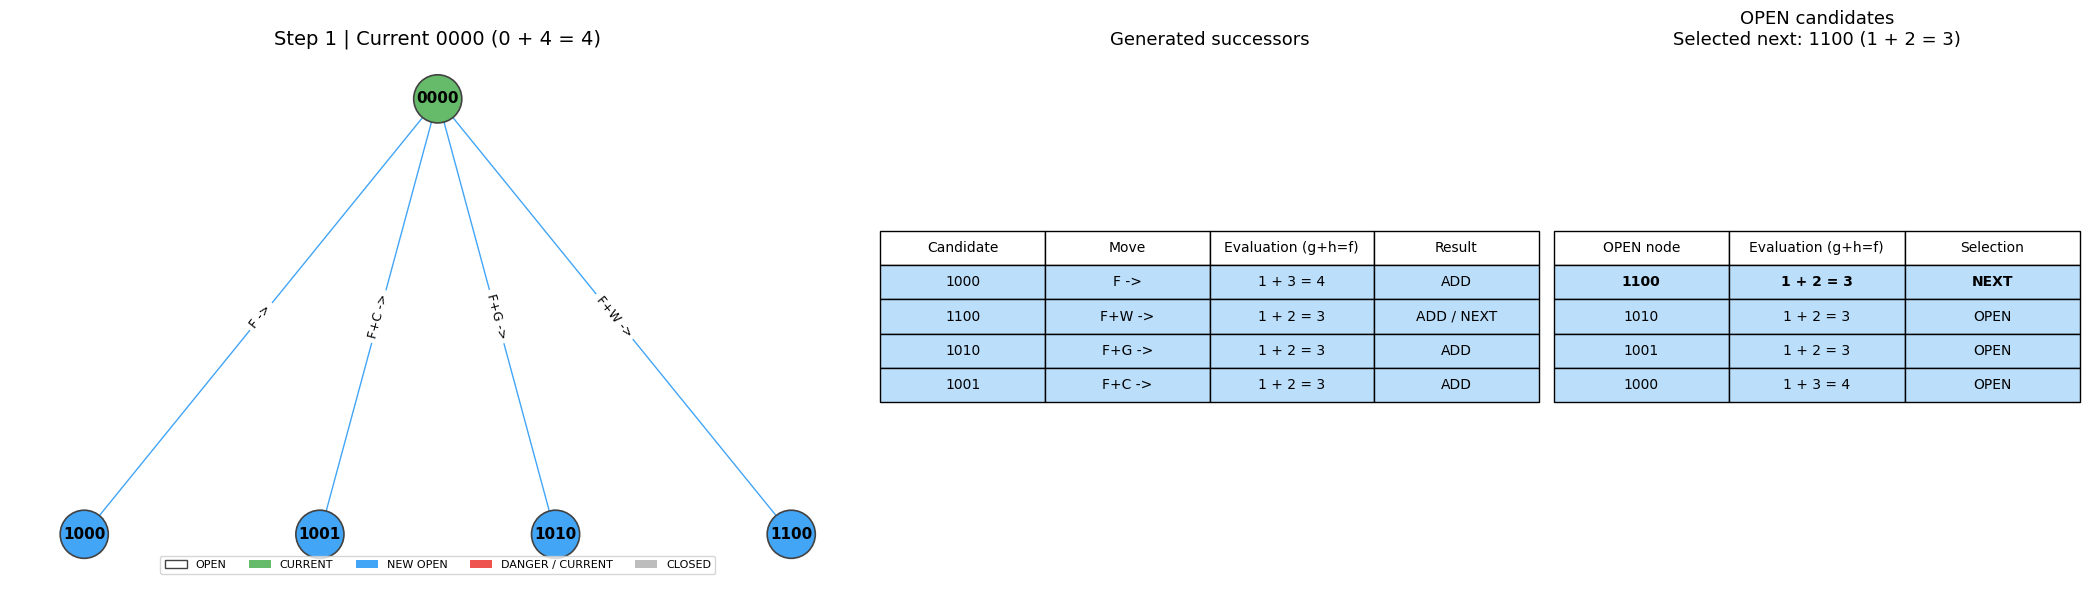

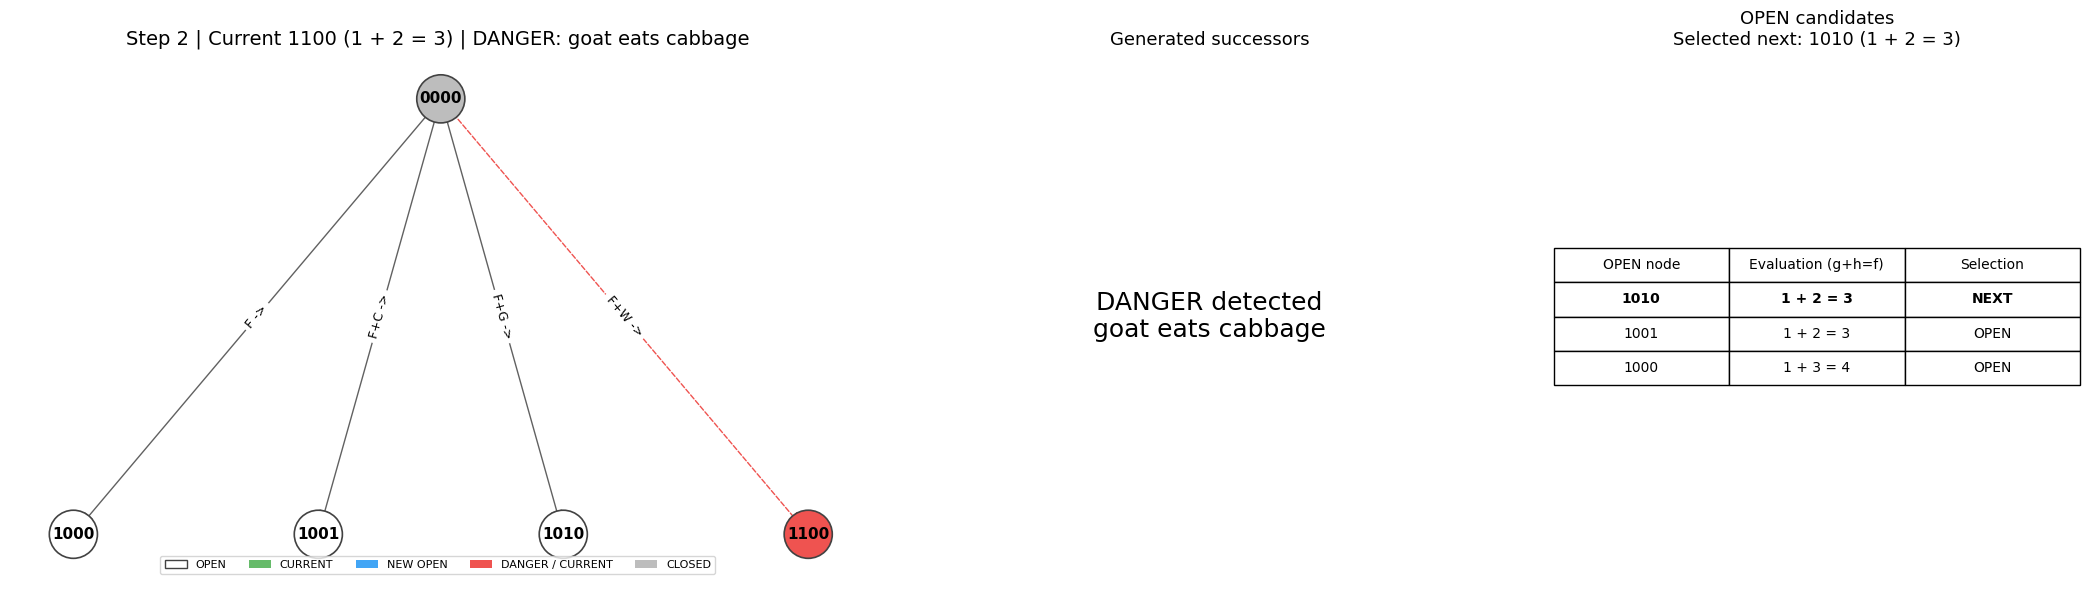

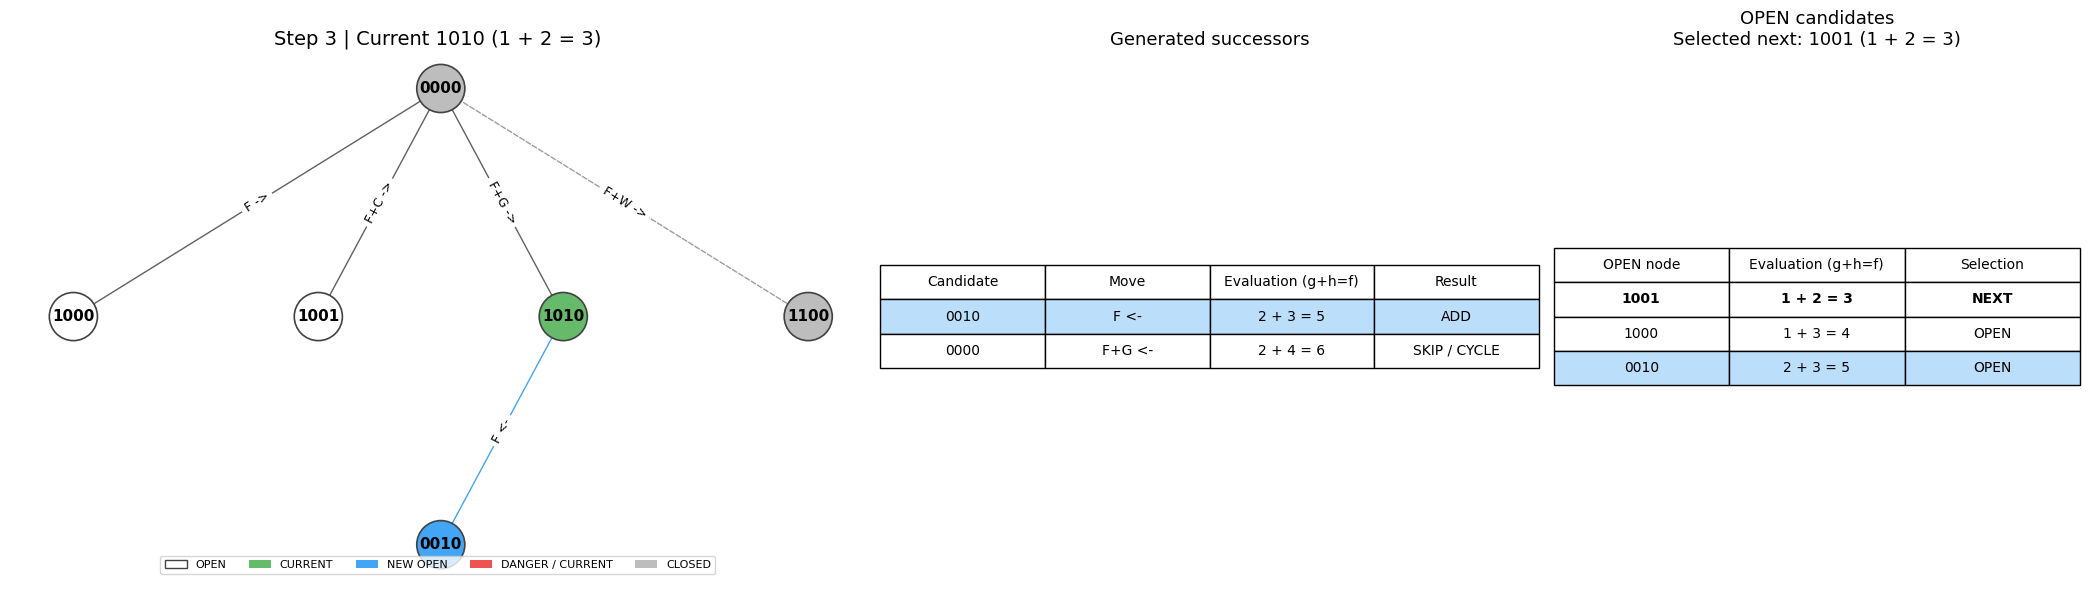

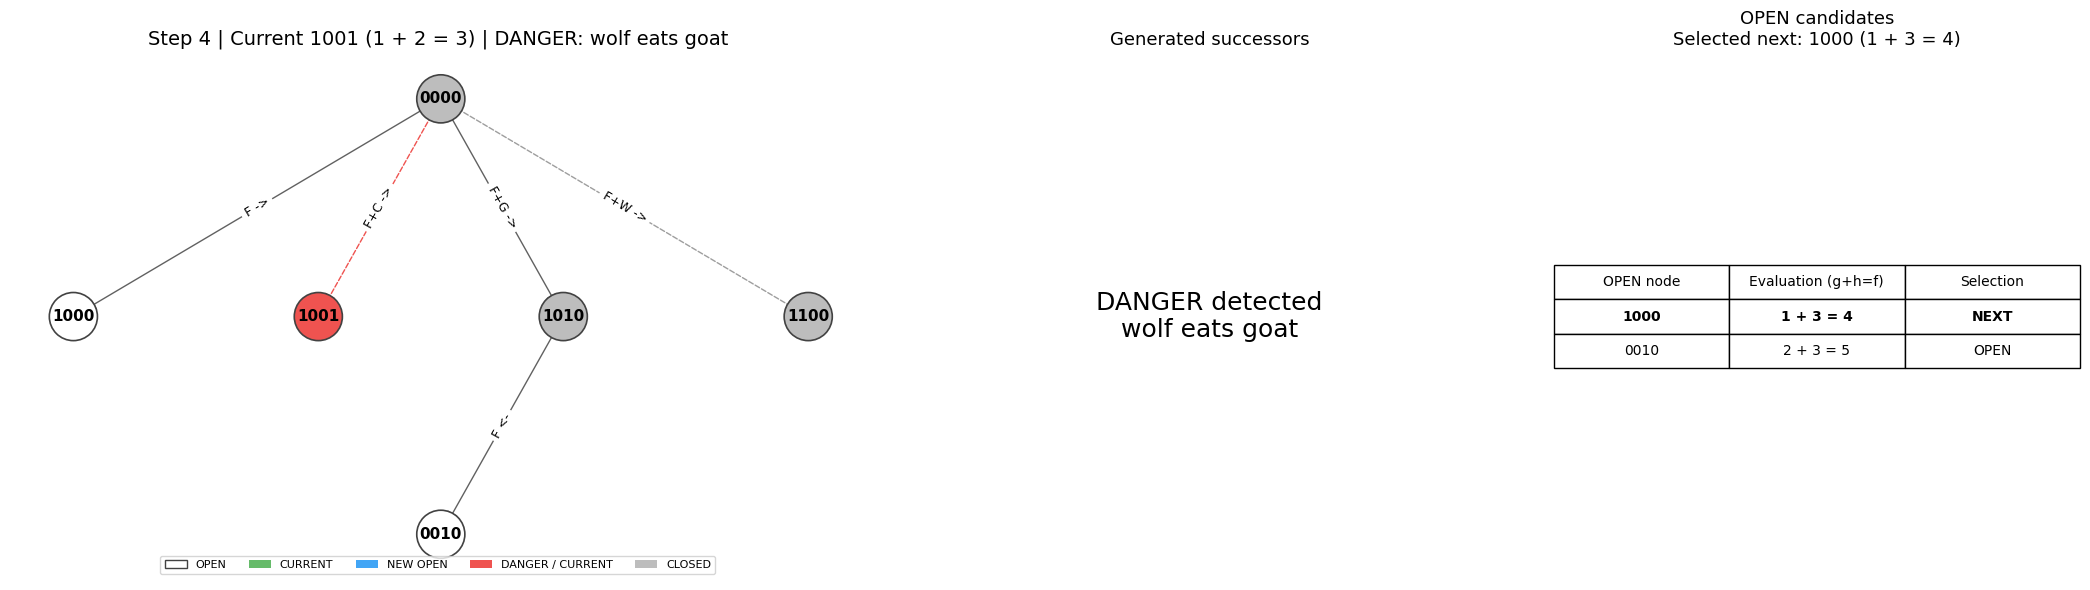

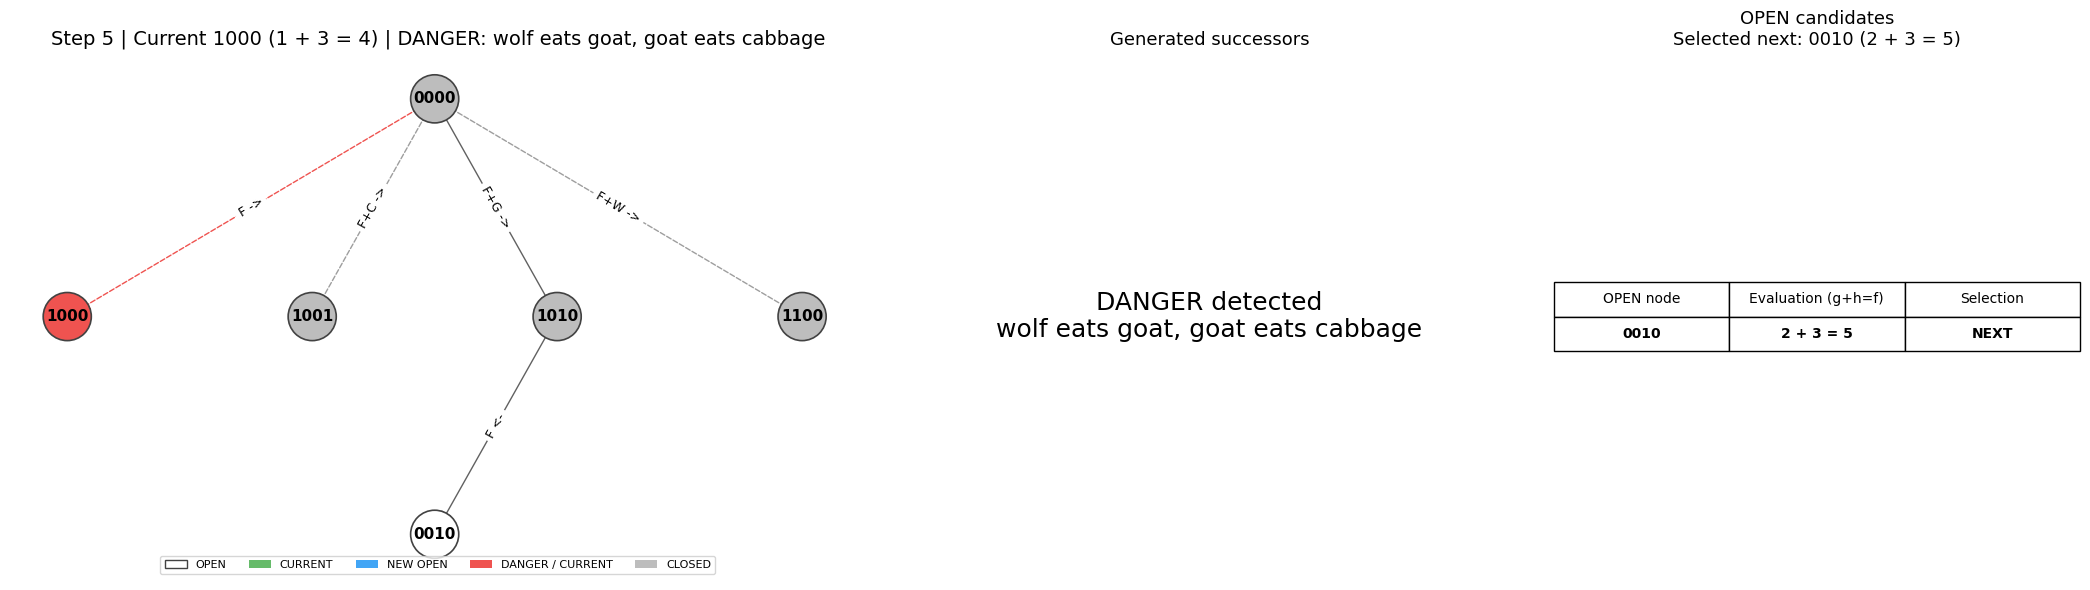

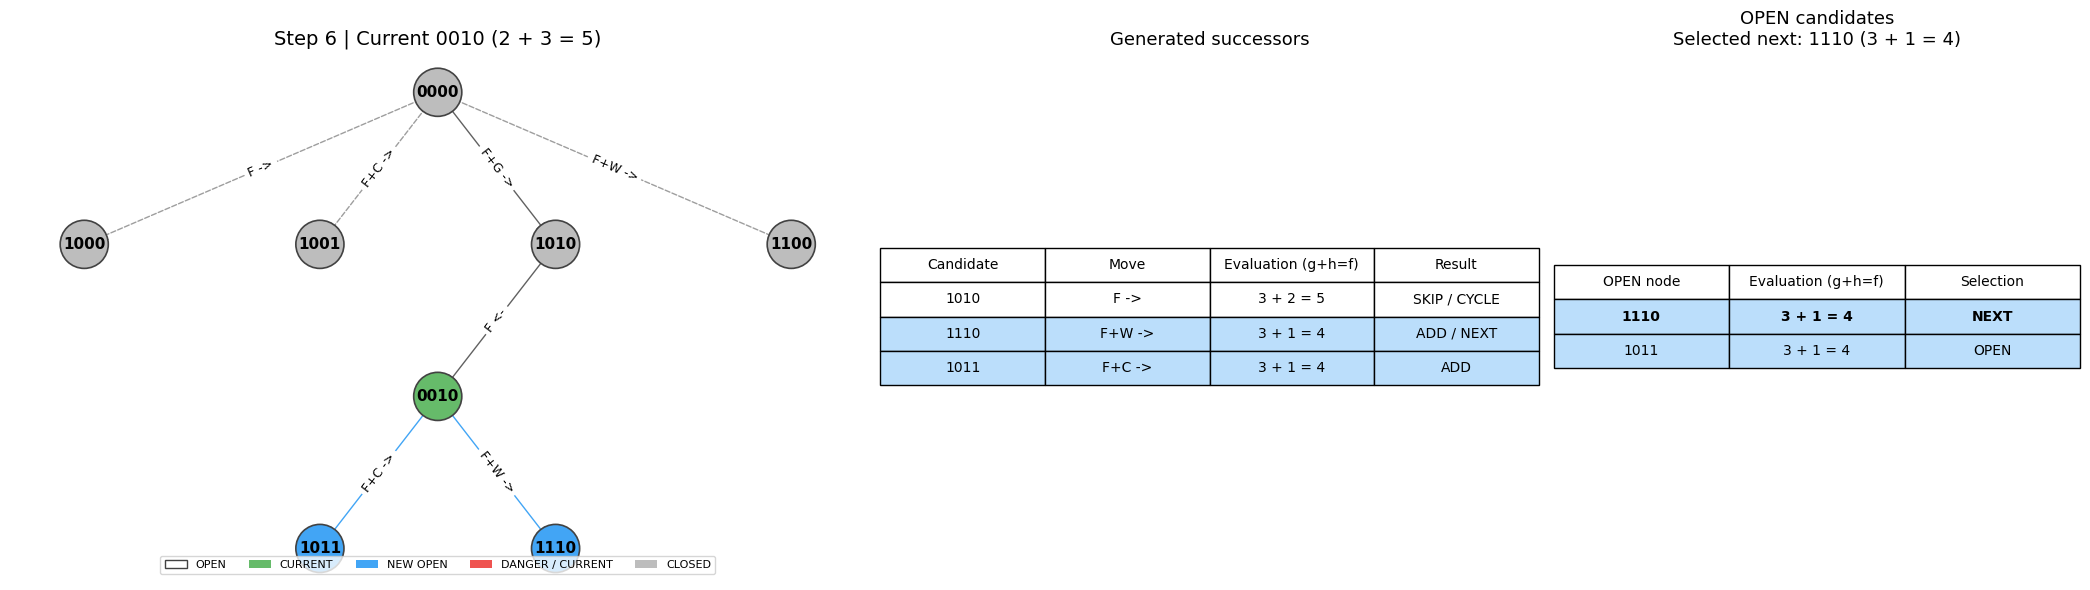

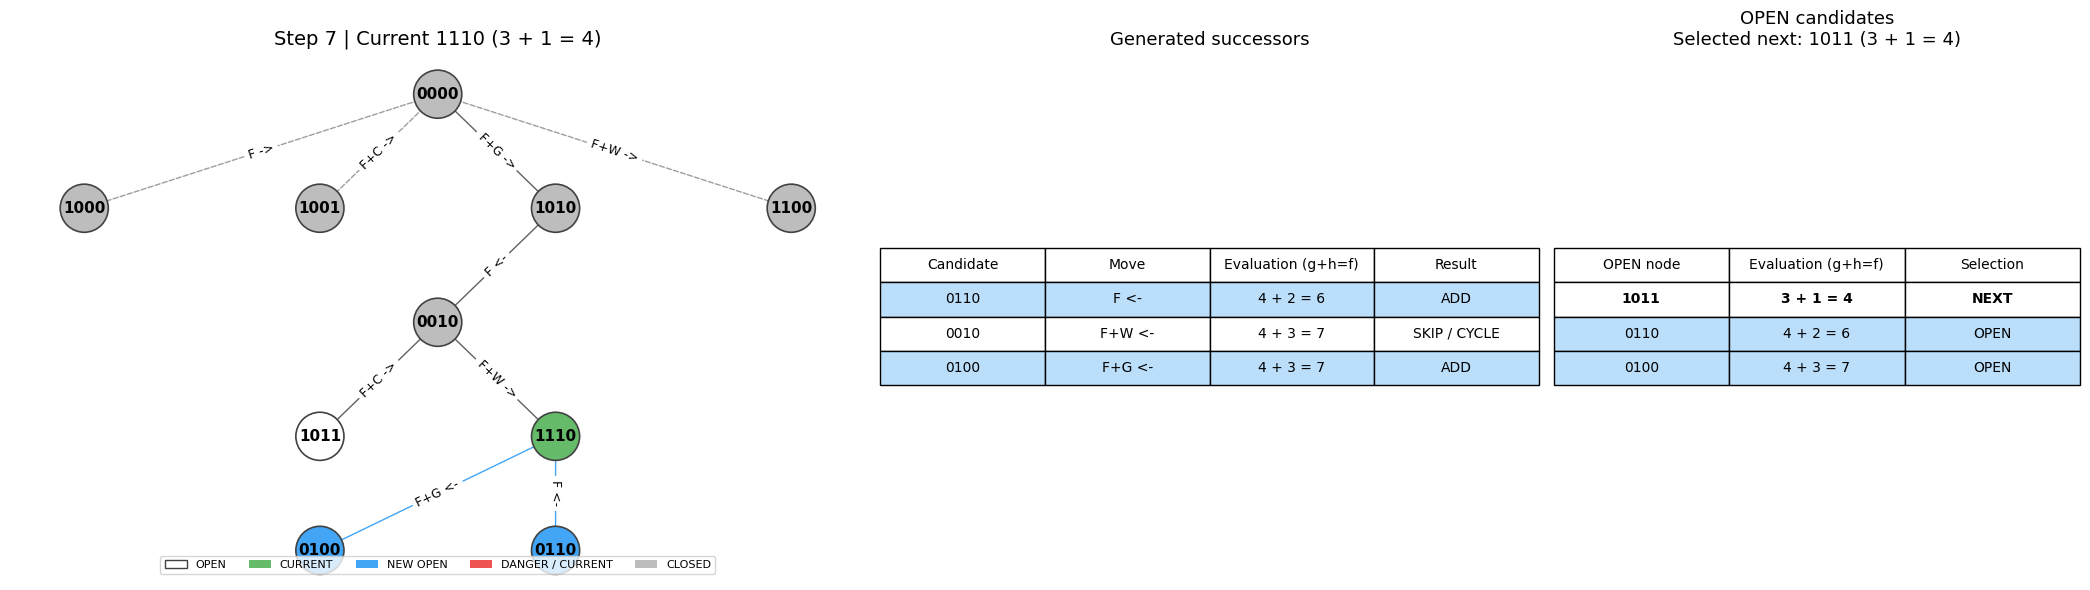

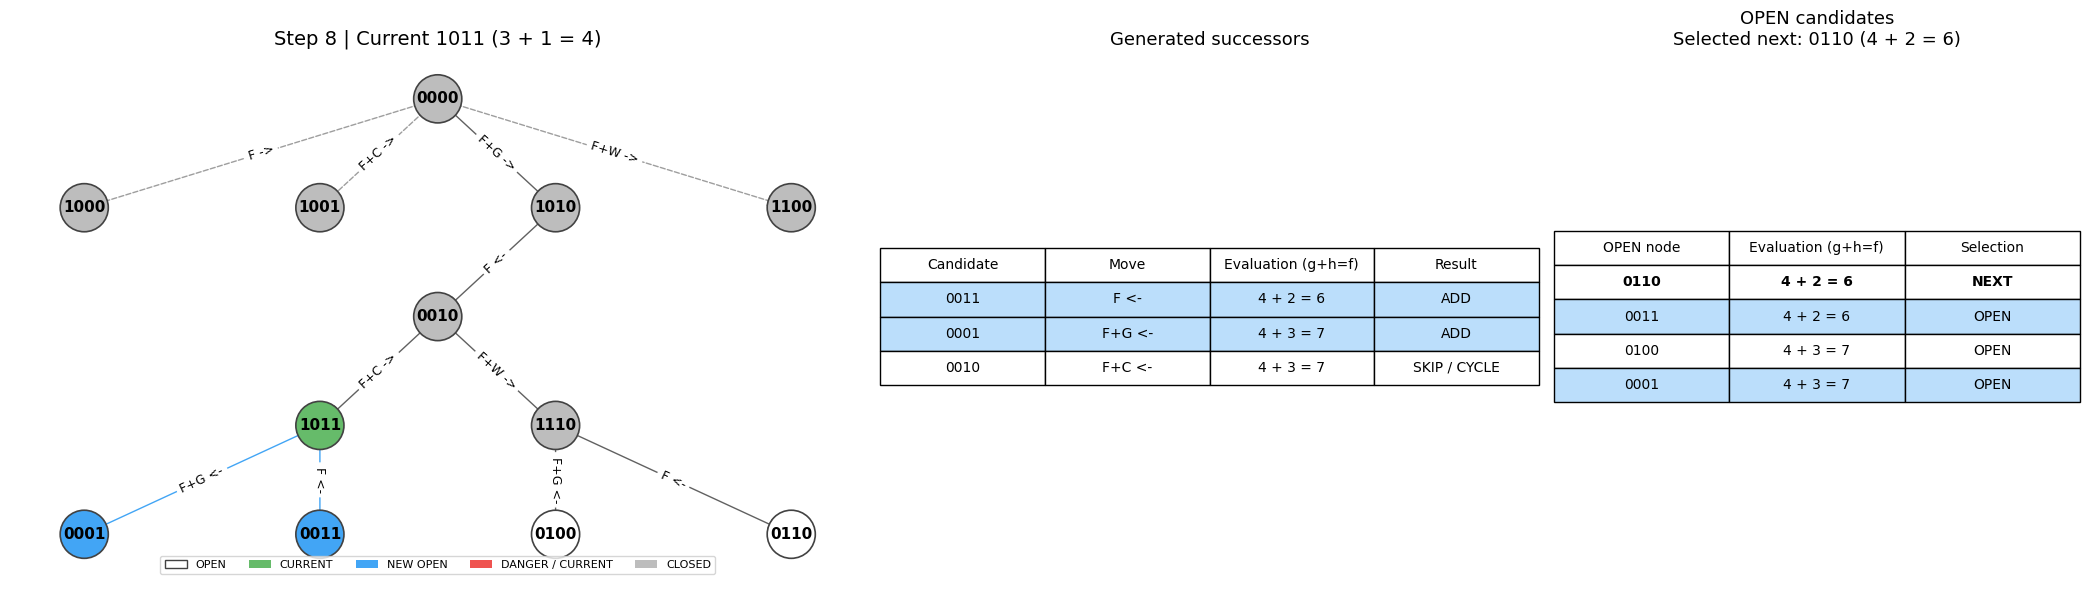

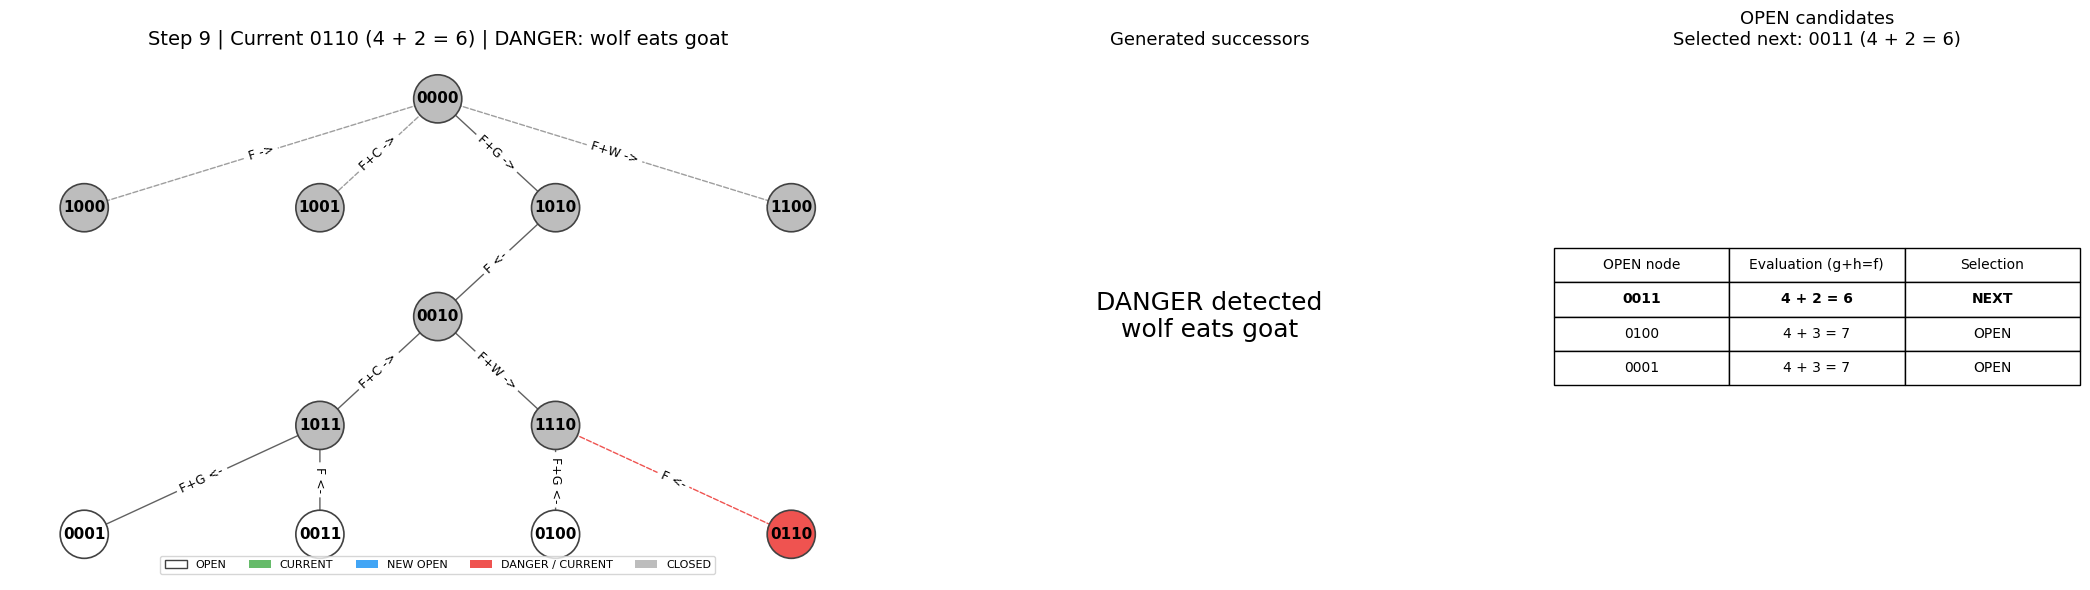

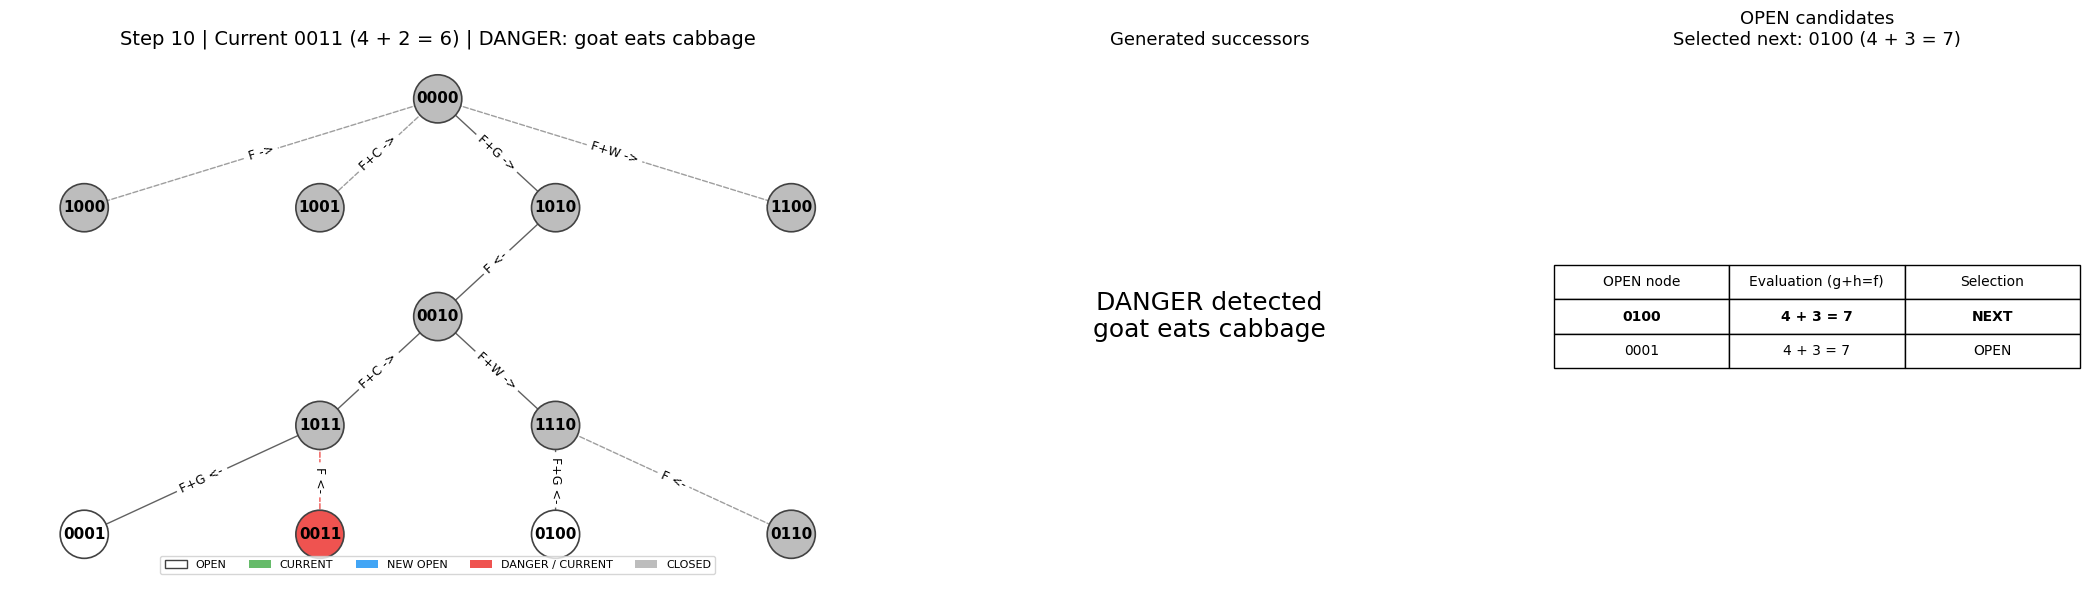

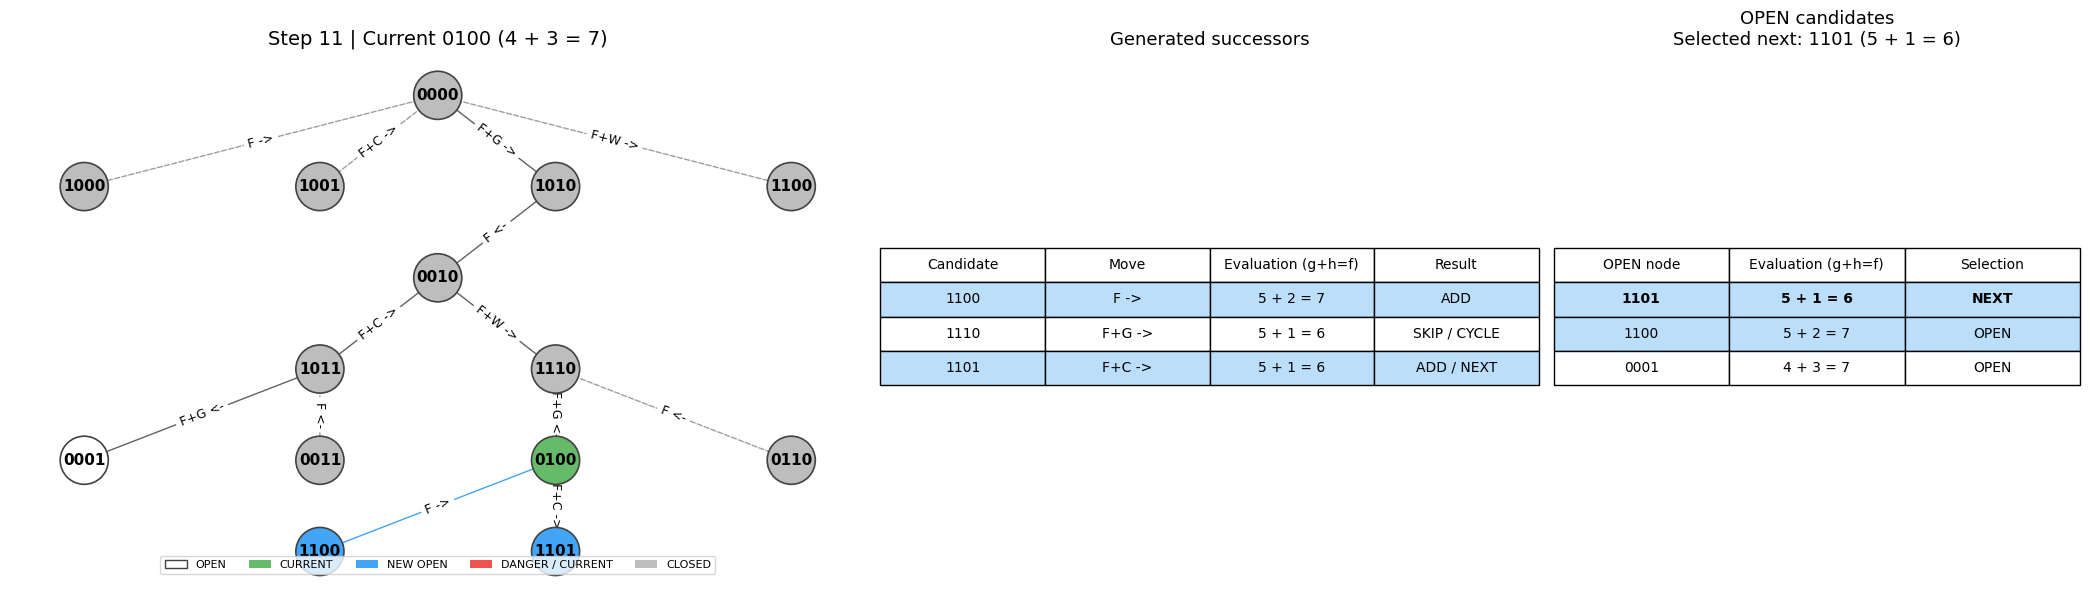

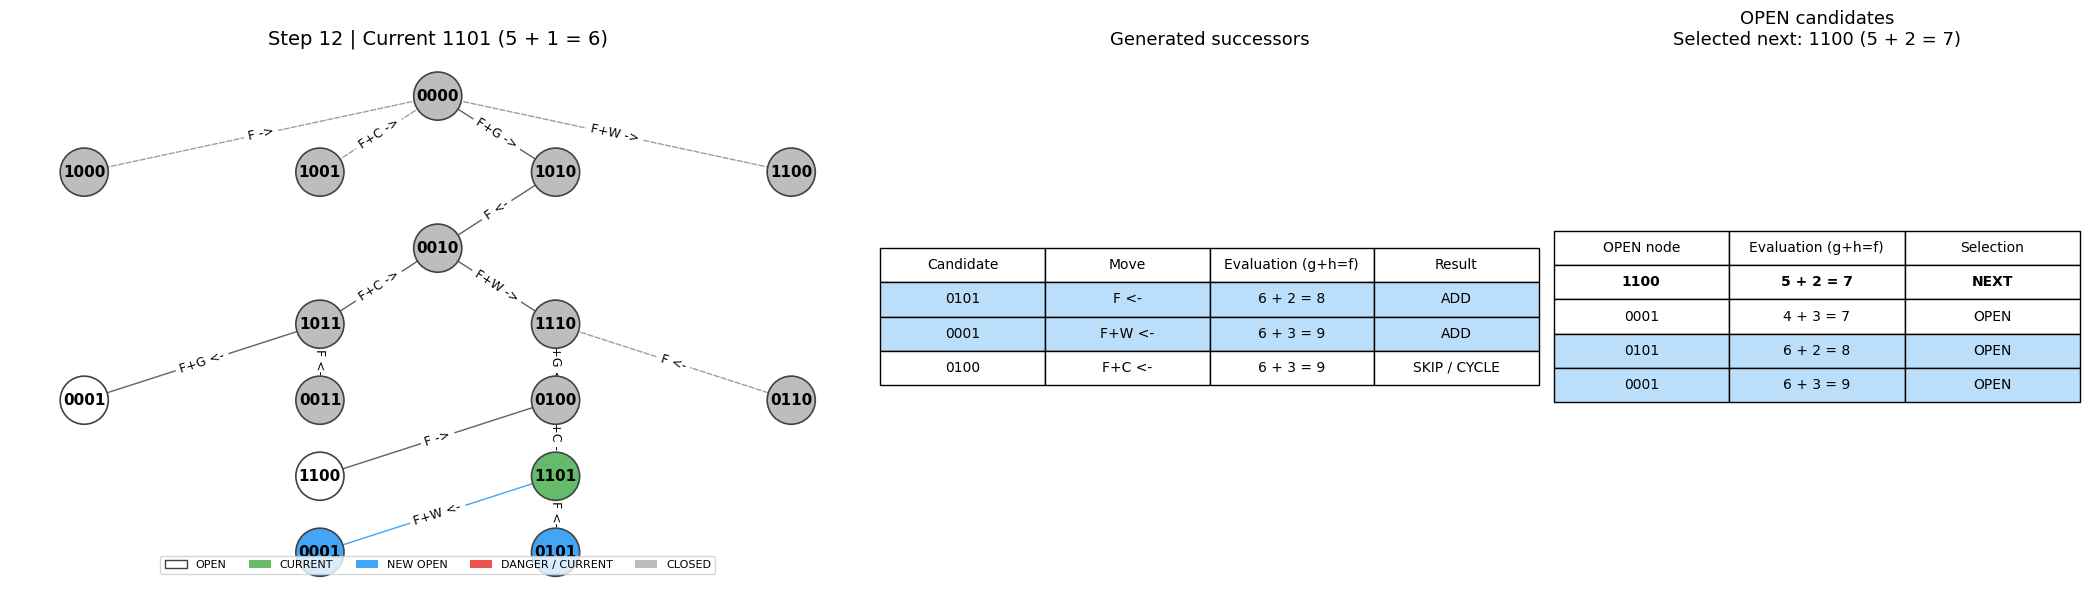

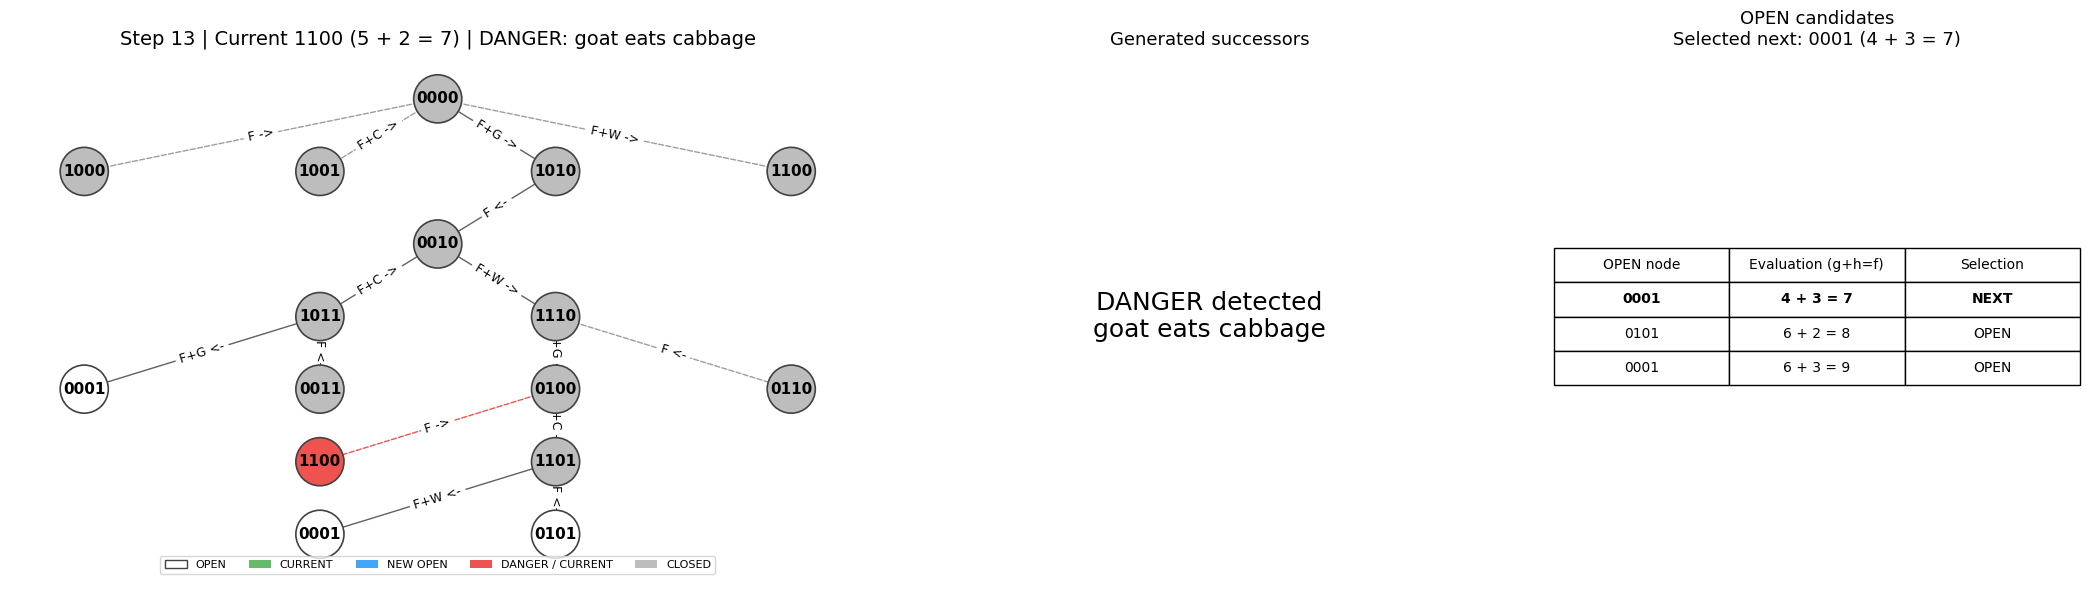

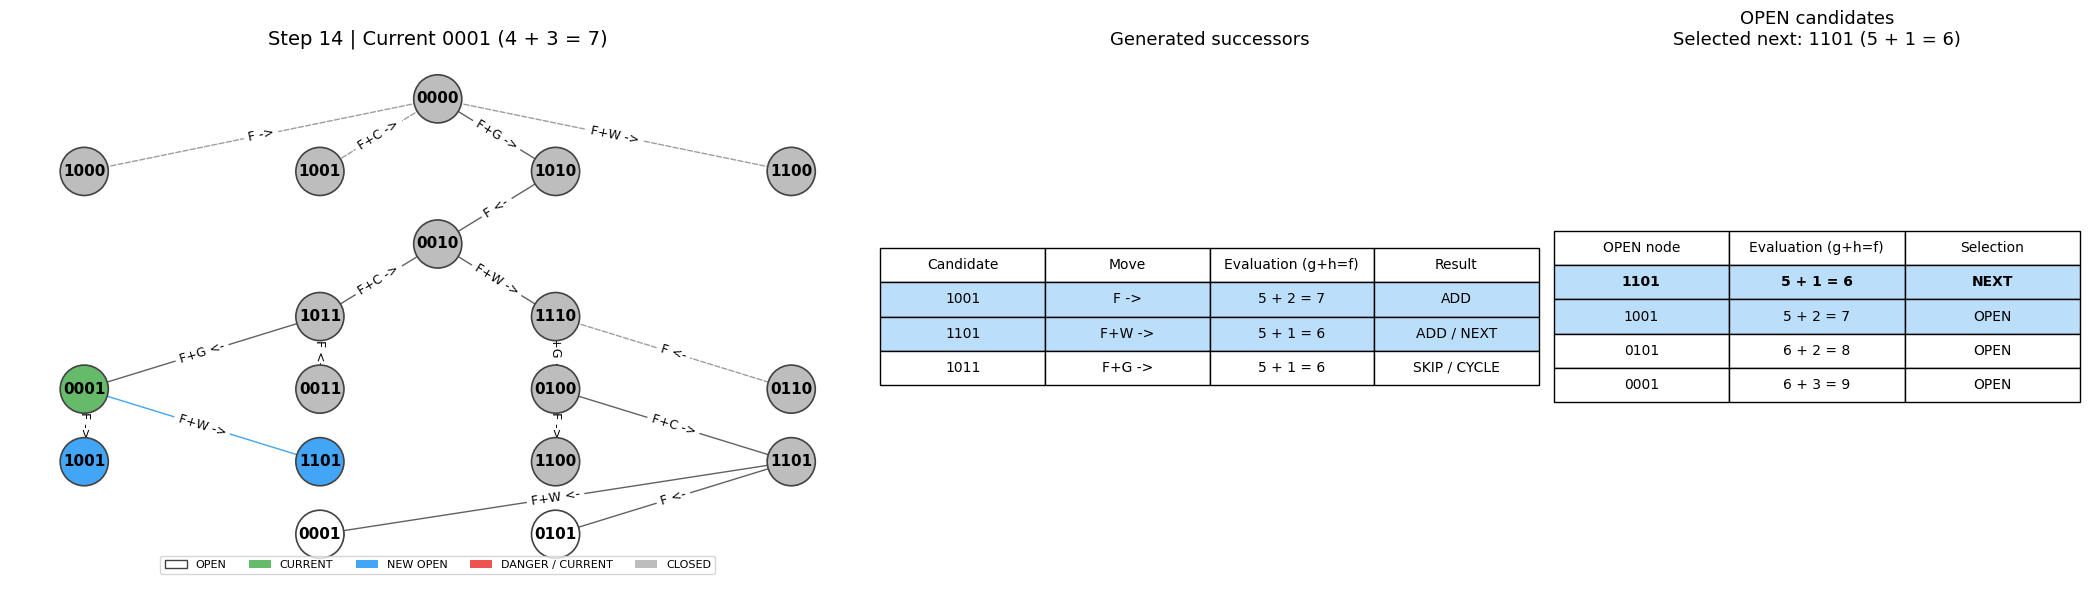

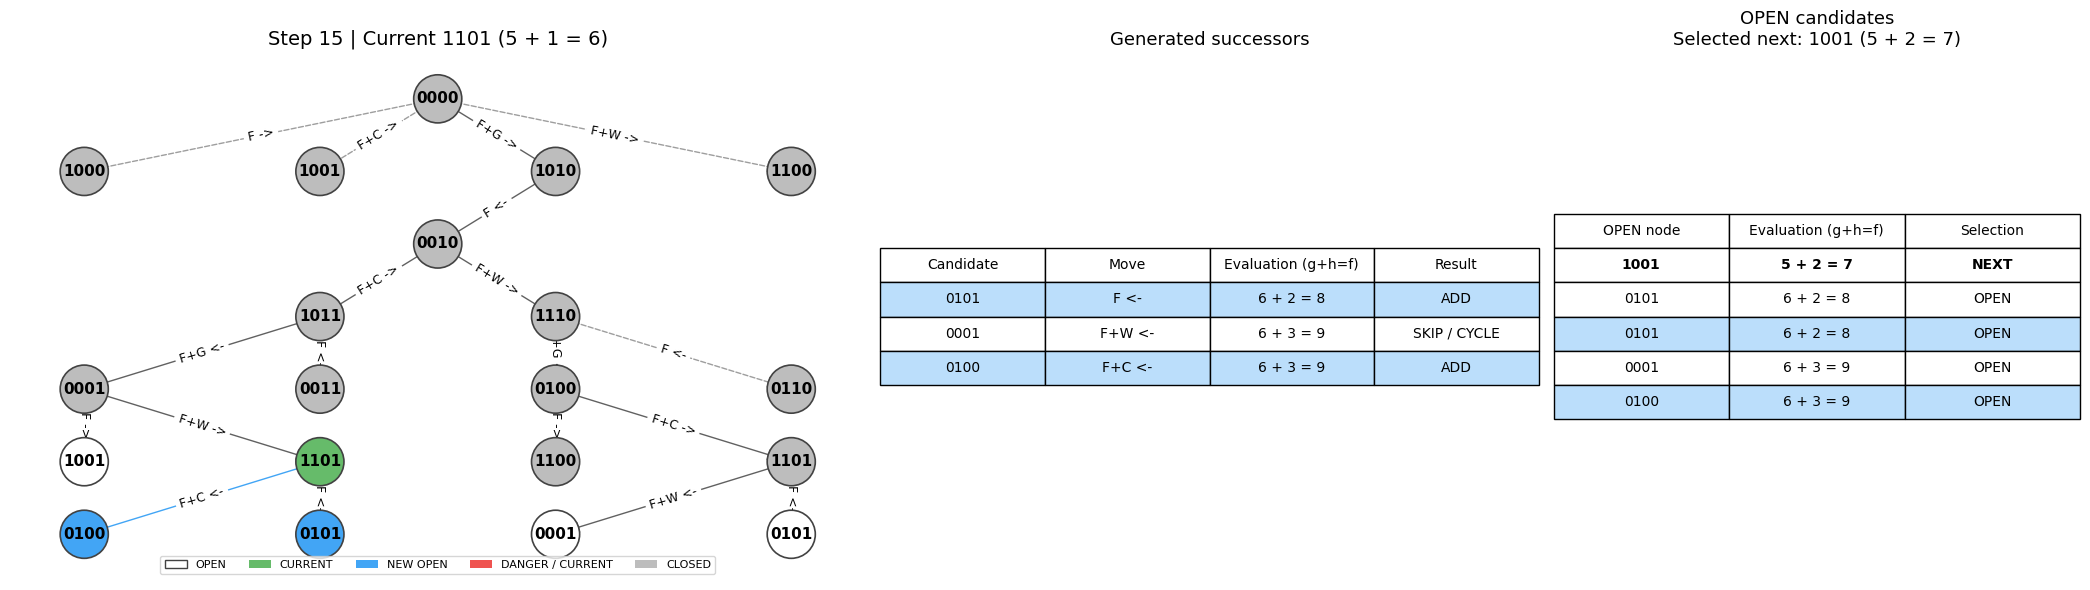

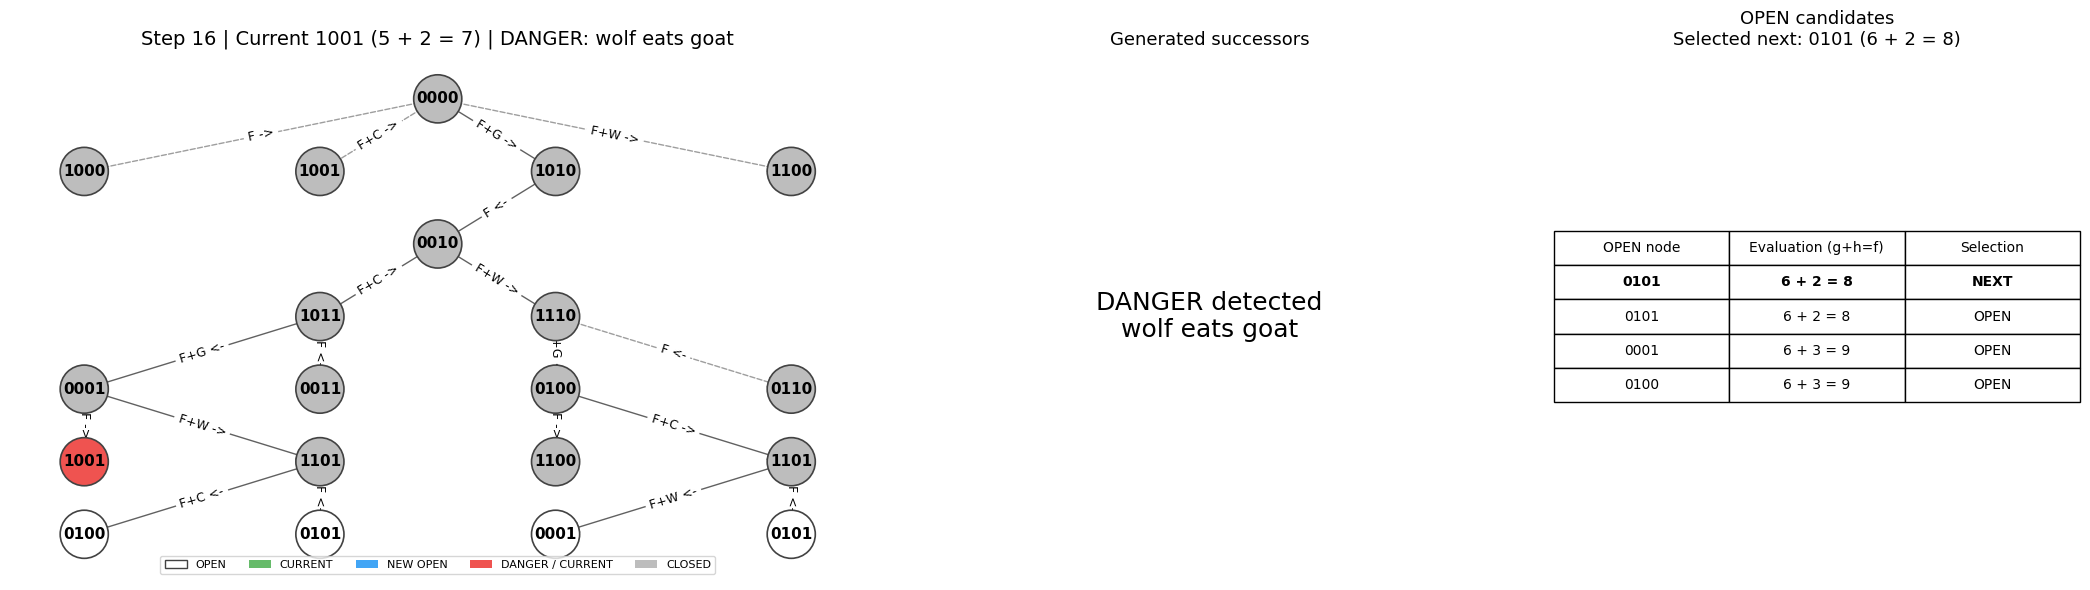

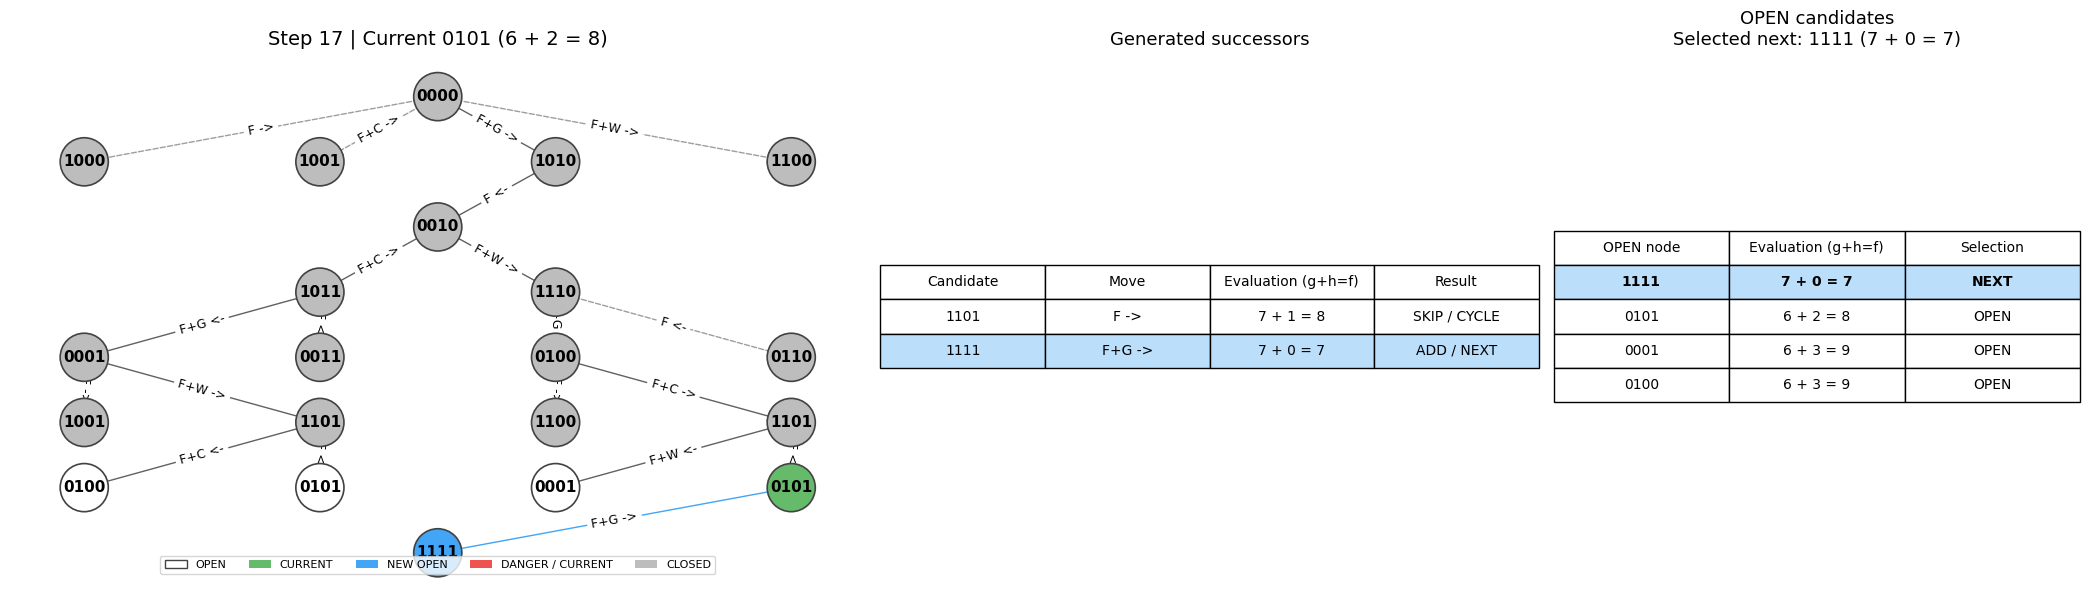

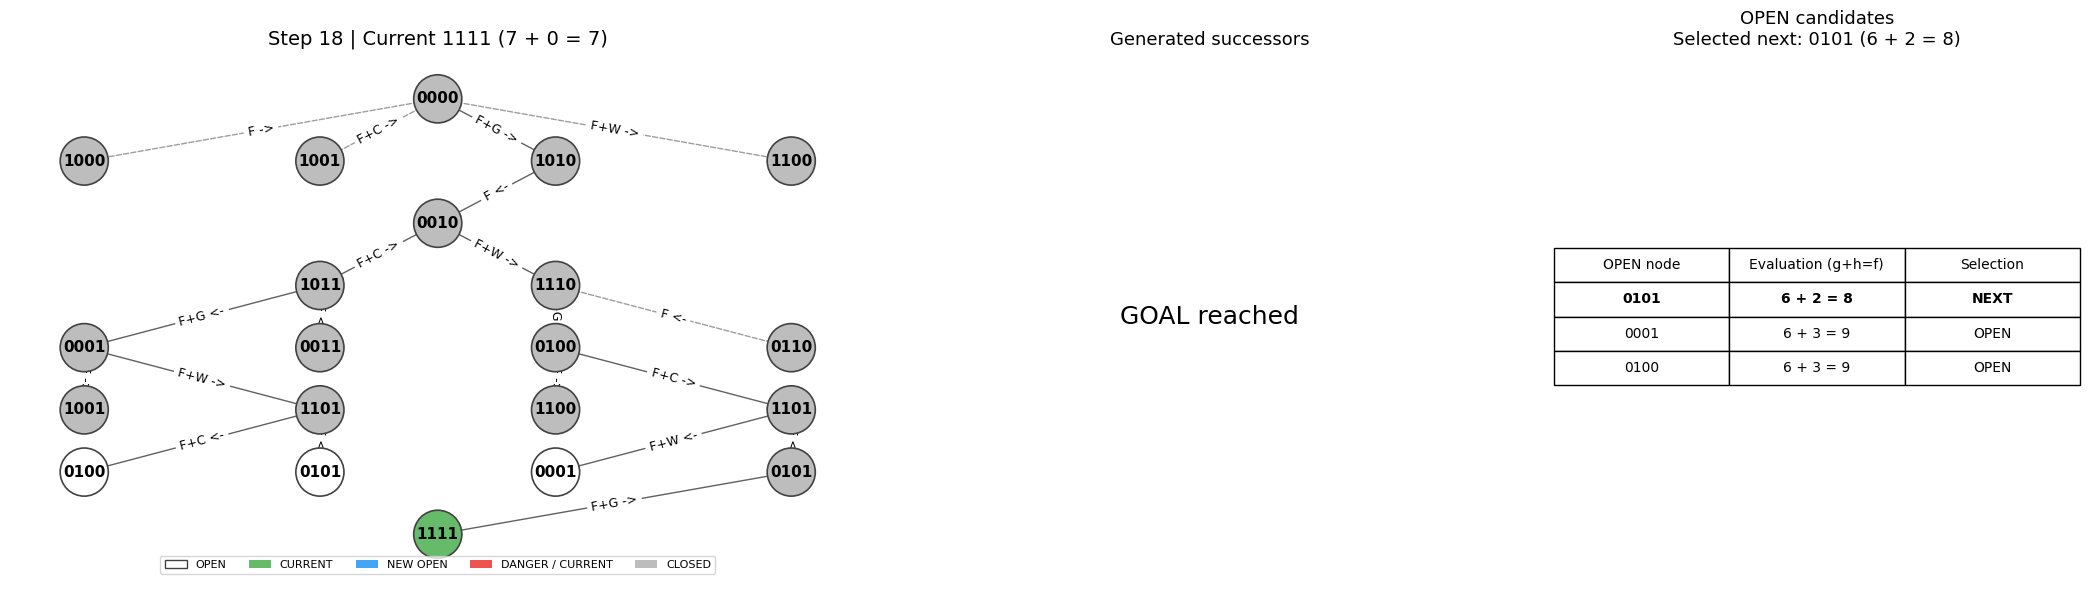

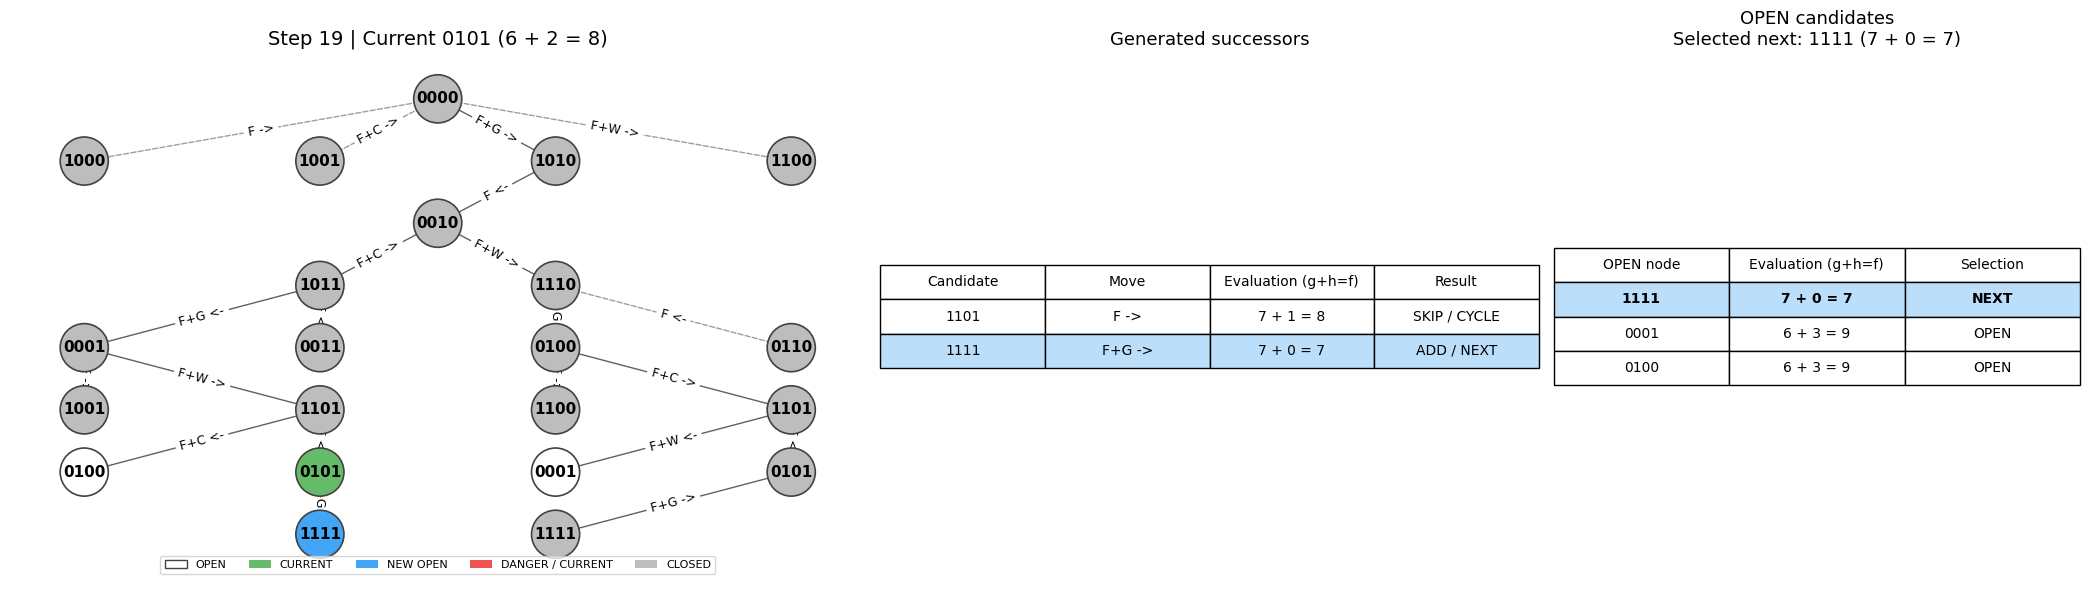

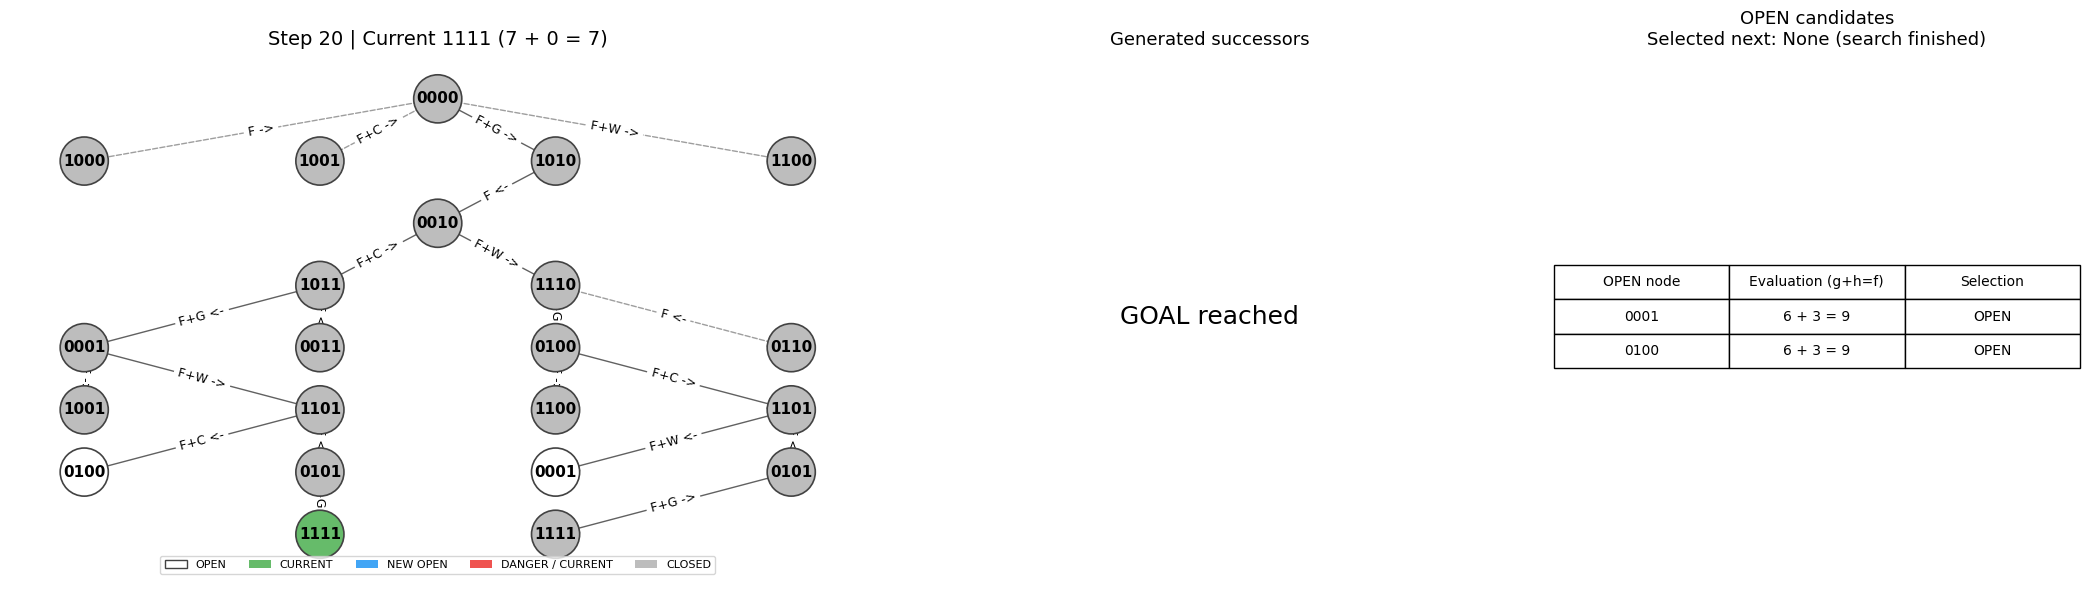

A* search complete: 20 steps, 2 shortest solutions found

Solution 1:
Start: 0000
1. 0000 -- Farmer with goat -> --> 1010
2. 1010 -- Farmer alone <- --> 0010
3. 0010 -- Farmer with wolf -> --> 1110
4. 1110 -- Farmer with goat <- --> 0100
5. 0100 -- Farmer with cabbage -> --> 1101
6. 1101 -- Farmer alone <- --> 0101
7. 0101 -- Farmer with goat -> --> 1111
Goal: 1111

Solution 2:
Start: 0000
1. 0000 -- Farmer with goat -> --> 1010
2. 1010 -- Farmer alone <- --> 0010
3. 0010 -- Farmer with cabbage -> --> 1011
4. 1011 -- Farmer with goat <- --> 0001
5. 0001 -- Farmer with wolf -> --> 1101
6. 1101 -- Farmer alone <- --> 0101
7. 0101 -- Farmer with goat -> --> 1111
Goal: 1111



In [42]:
def tree_positions(parent_map):
    root = next(node for node, previous in parent_map.items() if previous is None)
    depths = {root: 0}

    def get_depth(node):
        if node not in depths:
            depths[node] = get_depth(parent_map[node]) + 1
        return depths[node]

    for node in parent_map:
        get_depth(node)

    levels = {}
    for node, depth in depths.items():
        levels.setdefault(depth, []).append(node)

    positions = {}
    for depth, nodes in levels.items():
        nodes.sort()
        center = (len(nodes) - 1) / 2
        for index, node in enumerate(nodes):
            positions[node] = ((index - center) * 2.2, -depth * 1.5)
    return positions


legend_items = [
    Patch(facecolor="#ffffff", edgecolor="#424242", label="OPEN"),
    Patch(facecolor="#66bb6a", label="CURRENT"),
    Patch(facecolor="#42a5f5", label="NEW OPEN"),
    Patch(facecolor="#ef5350", label="DANGER / CURRENT"),
    Patch(facecolor="#bdbdbd", label="CLOSED"),
]


def draw_snapshot(snapshot):
    graph = nx.DiGraph()
    root = (START,)
    graph.add_node(root)
    for source, target, label in snapshot["tree_edges"]:
        graph.add_edge(source, target, label=label)
    for source, target, label in snapshot["danger_edges"]:
        graph.add_edge(source, target, label=label)

    snapshot_parents = {root: None}
    for source, target, _ in snapshot["tree_edges"]:
        snapshot_parents[target] = source
    for source, target, _ in snapshot["danger_edges"]:
        if target not in snapshot_parents:
            snapshot_parents[target] = source
    positions = tree_positions(snapshot_parents)

    current = snapshot["current"]
    next_node = snapshot["next"]
    node_colors = []
    for node in graph.nodes:
        if node == current:
            node_colors.append("#ef5350" if snapshot["current_danger_reasons"] else "#66bb6a")
        elif node in snapshot["new_danger"]:
            node_colors.append("#ef5350")
        elif node in snapshot["new_open"]:
            node_colors.append("#42a5f5")
        elif node in snapshot["open"]:
            node_colors.append("#ffffff")
        else:
            node_colors.append("#bdbdbd")

    fig, (ax_graph, ax_successors, ax_open) = plt.subplots(
        1, 3, figsize=(21, 6), gridspec_kw={"width_ratios": [1.3, 1, 0.8]}
    )
    visible_positions = {node: positions[node] for node in graph.nodes}
    nx.draw_networkx_nodes(
        graph,
        pos=visible_positions,
        node_color=node_colors,
        node_size=1200,
        edgecolors="#424242",
        linewidths=1.2,
        ax=ax_graph,
    )
    nx.draw_networkx_labels(
        graph,
        pos=visible_positions,
        labels={node: state_text(node[-1]) for node in graph.nodes},
        font_size=11,
        font_weight="bold",
        ax=ax_graph,
    )
    nx.draw_networkx_edges(
        graph,
        pos=visible_positions,
        edgelist=[
            (source, target)
            for source, target, _ in snapshot["tree_edges"]
            if target not in snapshot["new_open"]
        ],
        arrows=True,
        arrowsize=18,
        edge_color="#616161",
        ax=ax_graph,
    )
    nx.draw_networkx_edges(
        graph,
        pos=visible_positions,
        edgelist=[
            (source, target)
            for source, target, _ in snapshot["tree_edges"]
            if target in snapshot["new_open"]
        ],
        arrows=True,
        arrowsize=18,
        edge_color="#42a5f5",
        ax=ax_graph,
    )
    nx.draw_networkx_edges(
        graph,
        pos=visible_positions,
        edgelist=[
            (source, target)
            for source, target, _ in snapshot["danger_edges"]
            if target not in snapshot["new_danger"]
        ],
        arrows=True,
        arrowsize=18,
        edge_color="#9e9e9e",
        style="dashed",
        ax=ax_graph,
    )
    nx.draw_networkx_edges(
        graph,
        pos=visible_positions,
        edgelist=[
            (source, target)
            for source, target, _ in snapshot["danger_edges"]
            if target in snapshot["new_danger"]
        ],
        arrows=True,
        arrowsize=18,
        edge_color="#ef5350",
        style="dashed",
        ax=ax_graph,
    )
    nx.draw_networkx_edge_labels(
        graph,
        pos=visible_positions,
        edge_labels=nx.get_edge_attributes(graph, "label"),
        font_size=9,
        ax=ax_graph,
    )
    current_state = current[-1]
    current_g = len(current) - 1
    current_h = heuristic(current_state)
    ax_graph.set_title(
        f"Step {snapshot['step']} | Current {state_text(current_state)} "
        f"({current_g} + {current_h} = {current_g + current_h})"
        + (f" | DANGER: {', '.join(snapshot['current_danger_reasons'])}"
           if snapshot["current_danger_reasons"] else ""),
        fontsize=14,
    )
    ax_graph.legend(handles=legend_items, loc="lower center", ncol=5, fontsize=8)
    ax_graph.axis("off")

    columns = ["Candidate", "Move", "Evaluation (g+h=f)", "Result"]
    rows = [
        [
            state_text(row["state"]),
            row["move"],
            f"{row['g']} + {row['h']} = {row['f']}",
            row["result"],
        ]
        for row in snapshot["candidates"]
    ]
    ax_successors.axis("off")
    if rows:
        table = ax_successors.table(
            cellText=rows, colLabels=columns, cellLoc="center", loc="center"
        )
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 1.8)
        for row_index, row in enumerate(snapshot["candidates"], start=1):
            if "DANGER" in row["result"]:
                for column_index in range(len(columns)):
                    table[(row_index, column_index)].set_facecolor("#ffcdd2")
            elif row["result"].startswith("ADD"):
                for column_index in range(len(columns)):
                    table[(row_index, column_index)].set_facecolor("#bbdefb")
            elif row["result"] == "CLOSED":
                for column_index in range(len(columns)):
                    table[(row_index, column_index)].set_facecolor("#e0e0e0")
    else:
        message = (
            f"DANGER detected\n{', '.join(snapshot['current_danger_reasons'])}"
            if snapshot["current_danger_reasons"]
            else "GOAL reached"
        )
        ax_successors.text(0.5, 0.5, message, ha="center", va="center", fontsize=18)

    if next_node is None:
        next_text = "None (search finished)"
    else:
        next_state = next_node[-1]
        next_g = len(next_node) - 1
        next_h = heuristic(next_state)
        next_text = (
            f"{state_text(next_state)} "
            f"({next_g} + {next_h} = {next_g + next_h})"
        )
    ax_successors.set_title("Generated successors", fontsize=13)

    open_columns = ["OPEN node", "Evaluation (g+h=f)", "Selection"]
    open_rows = [
        [
            state_text(row["state"]),
            f"{row['g']} + {row['h']} = {row['f']}",
            "NEXT" if row["selected"] else "OPEN",
        ]
        for row in snapshot["open_candidates"]
    ]
    ax_open.axis("off")
    if open_rows:
        open_table = ax_open.table(
            cellText=open_rows,
            colLabels=open_columns,
            cellLoc="center",
            loc="center",
        )
        open_table.auto_set_font_size(False)
        open_table.set_fontsize(10)
        open_table.scale(1, 1.8)
        for row_index, row in enumerate(snapshot["open_candidates"], start=1):
            if row["node"] in snapshot["new_open"]:
                for column_index in range(len(open_columns)):
                    open_table[(row_index, column_index)].set_facecolor("#bbdefb")
            if row["selected"]:
                for column_index in range(len(open_columns)):
                    open_table[(row_index, column_index)].get_text().set_weight("bold")
    else:
        ax_open.text(0.5, 0.5, "OPEN is empty", ha="center", va="center")
    ax_open.set_title(f"OPEN candidates\nSelected next: {next_text}", fontsize=13)
    plt.tight_layout()
    plt.show()


path, actions, parents, edge_labels, snapshots, solutions = astar(
    START, GOAL, on_step=draw_snapshot
)
print(
    f"A* search complete: {len(snapshots)} steps, "
    f"{len(solutions)} shortest solutions found\n"
)
for solution_number, (solution_path, solution_actions) in enumerate(
    solutions, start=1
):
    print(f"Solution {solution_number}:")
    print_solution(solution_path, solution_actions)
    print()

## 결론

A* 탐색으로 찾은 최단 해는 7번의 이동이며, 안전한 최단 해는 2개입니다.

1. 염소를 오른쪽으로 옮긴다.
2. 농부가 혼자 왼쪽으로 돌아온다.
3. 늑대를 오른쪽으로 옮긴다.
4. 염소를 왼쪽으로 데려온다.
5. 양배추를 오른쪽으로 옮긴다.
6. 농부가 혼자 왼쪽으로 돌아온다.
7. 염소를 오른쪽으로 옮긴다.

3번과 5번의 늑대/양배추 이동 순서를 바꾼 경우도 안전한 최단 해가 됩니다. 두 경로를 모두 탐색하고 출력합니다.